In [1]:
from hapi import *
import numpy as np
from scipy import constants
import pycraf 
from astropy import units as u

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
import re
import numpy as np
import pandas as pd

def extract_o3_catalog(filepath):
    with open(filepath, 'r') as f:
        content = f.read()
        
    # Find the Tref
    match_tref = re.search(r"const\s+double\s+o3_Tref\s*=\s*([\d\.]+);", content)
    T_ref = float(match_tref.group(1)) if match_tref else 300.0
        
    # Find the catalog array
    match = re.search(r"const\s+cat_entry_t\s+o3_cat\[\]\s*=\s*\{([\s\S]*?)\};", content)
    if not match:
        raise ValueError("Could not find o3_cat in o3.c")
        
    block = match.group(1)
    
    # Clean comments and parse the rows
    block = re.sub(r'/\*.*?\*/', '', block, flags=re.DOTALL)
    lines = block.strip().split('\n')
    
    data = []
    for line in lines:
        line = line.strip().strip(',')
        if not line or line.startswith('//'):
            continue
            
        # Extract the 8 numbers in the struct
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", line)
        if len(nums) == 8:
            data.append([float(n) for n in nums])
            
    # Create DataFrame matching the struct blueprint
    columns = ['freq', 'S', 'Elo', 'gam_air', 'gam_self', 'nair', 'delta_air', 'iso']
    df_o3 = pd.DataFrame(data, columns=columns)
    
    return df_o3, T_ref

# Execute the extraction
o3_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o3.c'
df_o3, T_ref_o3 = extract_o3_catalog(o3_file_path)

print(f"Extracted {len(df_o3)} O3 lines. T_ref = {T_ref_o3} K")
print(df_o3.head())

Extracted 112876 O3 lines. T_ref = 296.0 K
       freq             S          Elo   gam_air  gam_self  nair  delta_air  \
0  0.789695  1.644062e-27   712.935074  0.002089  0.002811  0.81        0.0   
1  1.087765  2.786871e-27   751.839676  0.002083  0.002811  0.81        0.0   
2  2.594074  1.611684e-27  1527.521480  0.002044  0.002456  0.76        0.0   
3  5.028259  7.362903e-27  1080.935927  0.002435  0.003107  0.77        0.0   
4  5.923033  1.817642e-27  2016.599636  0.002015  0.002308  0.76        0.0   

   iso  
0  1.0  
1  1.0  
2  1.0  
3  1.0  
4  1.0  


In [63]:
def extract_struct_array(filepath, array_name):
    with open(filepath, 'r') as f:
        content = f.read()
    pattern = rf"{array_name}(?:\[.*?\])?\s*=\s*\{{([\s\S]*?)\}};"
    match = re.search(pattern, content)
    if not match: raise ValueError(f"Could not find {array_name}")
    
    rows = re.findall(r"\{([^}]+)\}", match.group(1))
    data = []
    for row in rows:
        row_clean = row.replace('f', '')
        numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", row_clean)
        data.append([float(n) for n in numbers])
    return np.array(data)

df_o3 = extract_struct_array(o3_file_path, 'o3_cat')

print(f"Extracted {len(df_o3)} O3 lines. T_ref = {T_ref_o3} K")
print(df_o3.shape)

Extracted 112876 O3 lines. T_ref = 296.0 K
(112876, 8)


In [65]:
import re
import numpy as np

def get_perfect_o3_data(filepath):
    """
    Extracts the O3 catalog table from o3.c and converts all units 
    to standard HITRAN units: cm^-1 and atm.
    """
    with open(filepath, 'r') as f:
        content = f.read()
        
    # 1. Extract T_ref (Usually 300K for JPL)
    match_tref = re.search(r"const\s+double\s+o3_Tref\s*=\s*([\d\.]+);", content)
    T_ref = float(match_tref.group(1)) if match_tref else 300.0
        
    # 2. Extract the catalog array robustly
    match = re.search(r"const\s+cat_entry_t\s+o3_cat\[\]\s*=\s*\{([\s\S]*?)\};", content)
    if not match:
        raise ValueError("Could not find o3_cat in o3.c")
        
    block = re.sub(r'/\*.*?\*/', '', match.group(1), flags=re.DOTALL)
    lines = block.strip().split('\n')
    
    data = []
    for line in lines:
        line = line.strip().strip(',')
        if not line or line.startswith('//'):
            continue
            
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", line)
        if len(nums) == 8:
            data.append([float(n) for n in nums])
            
    cat_matrix = np.array(data)
    
    # 3. Conversion Constants
    c  = 29.9792458 # GHz to cm^-1
    c2 = 1.4387770  # cm*K (Second radiation constant)
    P0 = 1013.25    # mbar (or hPa) to atm
    
    # Apply frequency mask (limit to < 1 THz)
    freq_GHz = cat_matrix[:, 0]
    mask = freq_GHz < 1001.0
    
    # 4. Apply HITRAN conversions
    f0_cm        = cat_matrix[mask, 0] / c
    S_ref_cm     = cat_matrix[mask, 1] / c         # [cm^2 * GHz] -> [cm^2 / cm^-1]
    E_low_cm     = cat_matrix[mask, 2] / c2        # [K] -> [cm^-1]
    gam_air_cm   = (cat_matrix[mask, 3] * P0) / c  # [GHz/mbar] -> [cm^-1 / atm]
    gam_self_cm  = (cat_matrix[mask, 4] * P0) / c  # [GHz/mbar] -> [cm^-1 / atm]
    n_air        = cat_matrix[mask, 5]             # Unitless
    delta_air_cm = (cat_matrix[mask, 6] * P0) / c  # [GHz/mbar] -> [cm^-1 / atm]
    
    return T_ref, f0_cm, S_ref_cm, E_low_cm, gam_air_cm, gam_self_cm, n_air, delta_air_cm

In [66]:
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o3.c'
T_ref, f0_cm, S_ref_cm, E_low_cm, gam_air_cm, gam_self_cm, n_air, delta_air_cm = get_perfect_o3_data(c_file_path)

In [30]:
print(f0_cm.shape)

(33676,)


In [67]:
import numpy as np
from hapi import partitionSum

def compute_o3_line_strength(T, f0_cm, S_ref, E_lower):
    """
    Computes O3 line strength using the exact Partition Sum from HAPI.
    """
    T_ref = 296.0
    c2 = 1.4387770 
    
    # ---------------------------------------------------------
    # 1. The True Partition Function Ratio (HAPI)
    # Molecule 3 = O3, Isotope 1 = Main isotope
    # ---------------------------------------------------------
    Q_ref = partitionSum(3, 1, T_ref)
    Q_T = partitionSum(3, 1, T)
    Q_ratio = Q_ref / Q_T
    
    # ---------------------------------------------------------
    # 2. The Rest of the Physics
    # ---------------------------------------------------------
    boltz_exponent = -c2 * E_lower * ((1.0 / T) - (1.0 / T_ref))
    boltz_factor = np.exp(boltz_exponent)
    
    stim_T = 1.0 - np.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - np.exp(-c2 * f0_cm / T_ref)
    stim_ratio = stim_T / stim_ref
    
    # Calculate final S(T) using the TRUE HAPI ratio
    S_T = S_ref * Q_ratio * boltz_factor * stim_ratio
    
    return S_T


def gross_shape(nu, nu0, gamma):
    """
    Computes the Gross line shape.
    """
    nu_grid = nu[:, None]
    nu0_arr = nu0[None, :]
    gamma_arr = gamma[None, :]
    
    numerator = 4.0 * (nu_grid**2) * gamma_arr
    denominator = ((nu_grid**2) - (nu0_arr**2))**2 + 4.0 * (nu_grid**2) * (gamma_arr**2)
    
    F_G = (1.0 / np.pi) * (numerator / denominator)
    
    return F_G


def compute_o3_line_width_cm(T, P_total_hPa, P_o3_hPa, gam_air, gam_self, n_temp):
    """ 
    Eq 3.11: Pressure and Temperature Broadened Line Width for trace gases.
    """
    P_total_atm = P_total_hPa / 1013.25
    P_o3_atm = P_o3_hPa / 1013.25
    
    temp_scaling = (296.0 / T) ** n_temp
    
    # Foreign broadening + Self broadening
    broadening = (gam_air * (P_total_atm - P_o3_atm)) + (gam_self * P_o3_atm)
    
    return temp_scaling * broadening


def compute_o3_line_shift_cm(P_total_hPa, f0_cm, delta_air):
    """ 
    Eq 3.12: Computes the pressure-induced line shift (nu*).
    Returns the shifted frequency in cm^-1.
    """
    # Convert total pressure to standard atmospheres
    P_total_atm = P_total_hPa / 1013.25
    
    # Calculate shift: nu* = nu0 + (delta * P_total)
    shifted_f_cm = f0_cm + (delta_air * P_total_atm)
    
    return shifted_f_cm


def calculate_o3_uncoupled_absorption(
    freq_grid_GHz, T, P_total_hPa, P_o3_hPa, 
    f0_cm, S_ref, gam_air, gam_self, n_temp, E_lower, delta_air
):
    """
    Calculates the total absorption cross-section of O3.
    """
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    # Expand dimensions for matrix broadcasting
    _f0 = f0_cm[None, :]
    _S_ref = S_ref[None, :]
    _gam_air = gam_air[None, :]
    _gam_self = gam_self[None, :]
    _n = n_temp[None, :]
    _E = E_lower[None, :]
    _delta = delta_air[None, :]
    
    # 1. Dynamic Line Strength
    S_T = compute_o3_line_strength(T, _f0, _S_ref, _E)
    
    # 2. Line Width and Shift
    gamma_width = compute_o3_line_width_cm(T, P_total_hPa, P_o3_hPa, _gam_air, _gam_self, _n)
    nu_star = compute_o3_line_shift_cm(P_total_hPa, _f0, _delta) 
    
    # 3. Line Shape Array
    F_G = gross_shape(nu_grid_cm, nu_star[0], gamma_width[0])
    
    # 4. Final integration across all lines
    return np.sum(S_T * F_G, axis=1)

In [68]:
frequencies_GHz = np.linspace(1, 1000, 10000)
T=220.0 # K
P_tot = 30.0 # hPa
P_o3 = 0.0 # hPa (to respect the am plot

k_o3 = calculate_o3_uncoupled_absorption(
    frequencies_GHz, T, P_tot, P_o3,
    f0_cm, S_ref_cm, gam_air_cm, gam_self_cm, n_air, E_low_cm, delta_air_cm
)

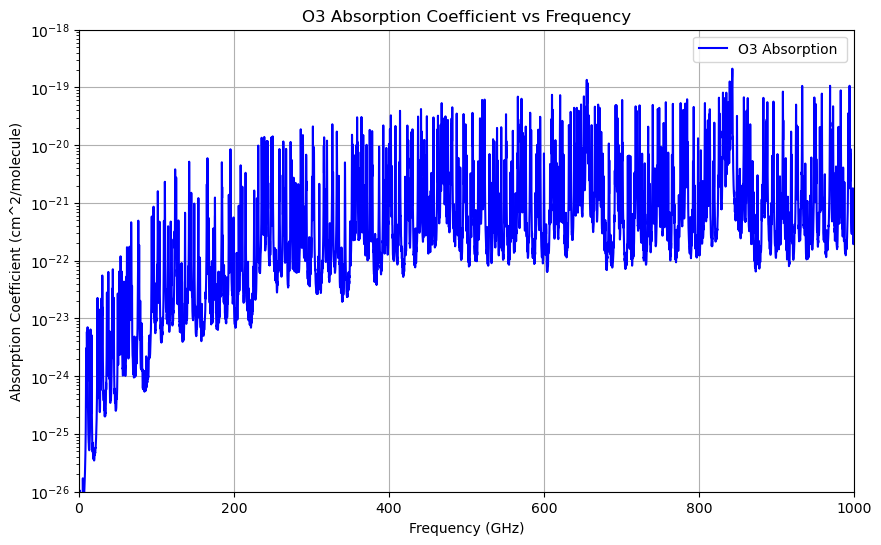

In [8]:
#Let's plot the result to compare with AM's plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(frequencies_GHz, k_o3, label='O3 Absorption ' ,color='blue')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Absorption Coefficient (cm^2/molecule)')
plt.title('O3 Absorption Coefficient vs Frequency')
plt.xlim(0, 1000)
plt.yscale('log')
plt.ylim(1e-26, 1e-18)
plt.grid()
plt.legend()
plt.show()

In [9]:
#Let's have a look at an ERA5 ozone profile
import xarray as xr

o3file = '/pscratch/sd/s/shamikg/atmo3_data/era5/2023/o3.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
geoptfile = '/pscratch/sd/s/shamikg/atmo3_data/era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

o3_data = xr.open_dataset(o3file)
geopt_data = xr.open_dataset(geoptfile)

import jax.numpy as jnp

# Site parameters
site_altitude = 5100.0
site_lon = -67.78
site_lat = -22.95

# 2. Interpolate spatially to the exact APEX coordinates
# ERA5 longitude convention: -67.78 + 360 = 292.22
o3_at_site = o3_data.interp(latitude=site_lat, longitude=site_lon + 360.0)

# 3. Collapse the time dimension to get the standard monthly mean
o3_mean_profile = o3_at_site.mean(dim='time')

# 4. Extract the values, convert to a JAX array, and reverse the vertical 
# axis ([::-1]) so it goes from the ground (5100m) up to space.
o3_mean_1d = jnp.asarray(o3_mean_profile['o3'].values)[::-1]

In [10]:
from scipy import constants as con
# 1. Open the geopotential dataset
geopt_dataset = xr.open_dataset(geoptfile)

# 2. Interpolate spatially to the exact APEX coordinates
geopt_at_site = geopt_dataset.interp(latitude=site_lat, longitude=site_lon + 360.0)

# 3. Collapse the time dimension to get the monthly mean
geopt_mean_dataset = geopt_at_site.mean(dim='time')

# 4. Extract the geopotential variable ('z'), divide by gravity, and reverse order
# (If your specific file uses a different variable name like 'geopt', just swap 'z' for that)
altitude_1d = jnp.asarray(geopt_mean_dataset['geopt'].values / con.g)[::-1]

In [11]:
tempfile = '/pscratch/sd/s/shamikg/atmo3_data/era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ta_data = xr.open_dataset(tempfile)
ta_at_site = ta_data.interp(latitude=site_lat, longitude=site_lon + 360.0)
ta_mean_profile = ta_at_site.mean(dim='time')
ta_mean_1d = jnp.asarray(ta_mean_profile['ta'].values)[::-1]  

import xarray as xr
import jax.numpy as jnp
import scipy.constants as con

# --- 1. Extract Pressure Profile ---
# Assuming 'dataset' is your xr.open_dataset(o3file) from the previous step
# The ERA5 'level' coordinate is in hPa. We multiply by 100 to get Pascals.
# We reverse it ([::-1]) to match the bottom-up orientation of your other arrays.
pressure_hPa = o3_data.level.values[::-1]
pressure_Pa = jnp.asarray(pressure_hPa * 100.0)

# --- 2. Define Physical Constants ---
M_air = 28.9647e-3 # Molar mass of dry air in kg/mol
M_o3 = 47.9982e-3  # Molar mass of Ozone (O3) in kg/mol

# --- 3. Calculate Number Density (molecules / m^3) ---
# Calculate total number density of air molecules
n_air = pressure_Pa / (con.k * ta_mean_1d)

# Convert ozone mass mixing ratio to volume mixing ratio
vmr_o3 = o3_mean_1d * (M_air / M_o3)

# Calculate final ozone number density
o3_density_molecules_m3 = vmr_o3 * n_air

In [12]:
print(ta_mean_1d)

[297.3529  296.26984 295.16553 294.04367 292.90454 291.70215 290.48932
 289.24518 287.9855  286.6556  285.3216  282.5175  279.41827 276.08194
 270.9521  265.62567 260.4484  254.57452 247.47375 239.0343  229.89682
 225.23593 220.28123 214.79968 208.95433 203.57466 199.63814 201.9812
 212.18654 217.7042  221.02812 230.10208 233.20029 238.76564 252.6394
 261.24075 262.1027 ]


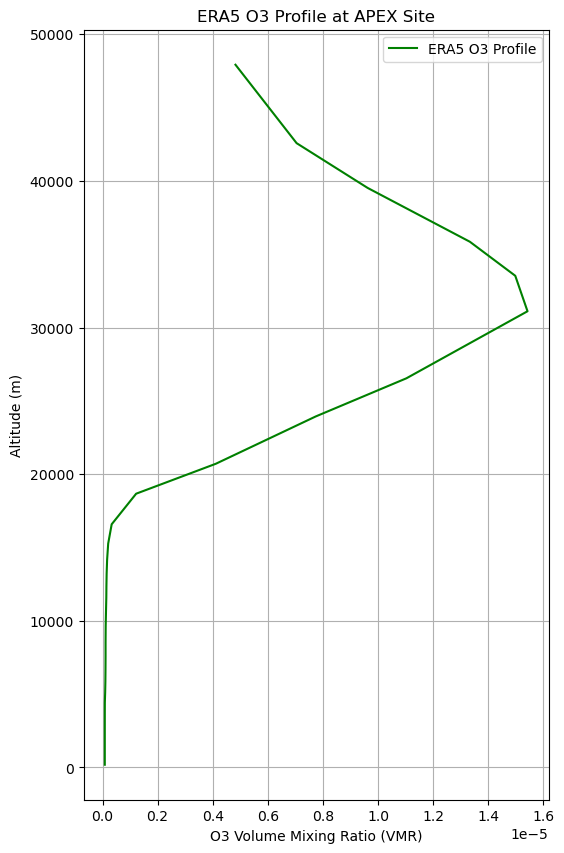

In [13]:
#Let's plot the ozone profile
plt.figure(figsize=(6, 10))
plt.plot(o3_mean_1d, altitude_1d, label='ERA5 O3 Profile', color='green')
plt.xlabel('O3 Volume Mixing Ratio (VMR)')
plt.ylabel('Altitude (m)')
plt.title('ERA5 O3 Profile at APEX Site')
plt.grid()
plt.legend()
plt.show()  

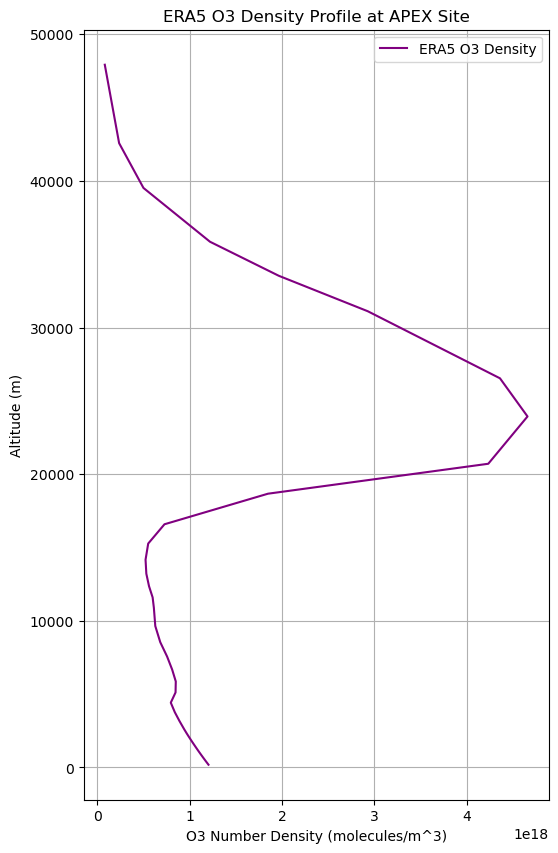

In [14]:
#Let's plot the ozone density profile
plt.figure(figsize=(6, 10))
plt.plot(o3_density_molecules_m3, altitude_1d, label='ERA5 O3 Density', color='purple')
plt.xlabel('O3 Number Density (molecules/m^3)')
plt.ylabel('Altitude (m)')
plt.title('ERA5 O3 Density Profile at APEX Site')
plt.grid()
plt.legend()
plt.show()

In [15]:
# Now, let's interp the o3 density to a common linspace grid going from 5000m to 45000m
altitude_grid = jnp.linspace(5000.0, 45000.0, 100)  # 100 points from 5km to 45km
o3_density_interp = jnp.interp(altitude_grid, altitude_1d, o3_density_molecules_m3)

dz_O3 = np.diff(altitude_grid, prepend = [altitude_grid[0]])

In [16]:
#Now that we have k_O3 and o3_density interp, let's compute the absorption coefficient profile by multiplying them together
#k_O3 is an array the same length as the frquency grid we defined earlier, and o3_density_interp is the O3 number density at each altitude in our new grid.
absorption_profile = k_o3[:, None] * 0.1 * o3_density_interp[None, :] # in m-1 

#Let's convert now in dB/km (ie convert from m-1 to km-1 and then to dB)

gamma_o3 = absorption_profile  * 10.0 / np.log(10) # in dB/km


Here, we'll try to quantify which lines of 03 should we keep

In [17]:
# Let's have a standardized profile for temperature and pressure from pycraf

altitudes = np.geomspace(1, 25000, 100) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

# We have the altitude profile, let's have an array containing the dz between each layer but with the same shape as the altitudes array for broadcasting purposes
dz = np.diff(altitudes, prepend=altitudes[0]) #m

In [18]:
print(altitudes)

[ 5000.          5000.10770378  5000.22700766  5000.35916102
  5000.50554779  5000.66770097  5000.84731867  5001.04628186
  5001.26667415  5001.51080352  5001.78122654  5002.08077514
  5002.41258626  5002.78013468  5003.18726947  5003.6382542
  5004.1378117   5004.69117342  5005.30413429  5005.98311337
  5006.73522105  5007.56833357  5008.49117546  5009.5134109
  5010.64574496  5011.90003567  5013.28941824  5014.82844255
  5016.53322559  5018.4216202   5020.51340205  5022.8304767
  5025.39710904  5028.24017738  5031.38945492  5034.87792154
  5038.74210919  5043.02248445  5047.76387228  5053.0159255
  5058.83364468  5065.27795419  5072.41634017  5080.32355728
  5089.08241153  5098.78462747  5109.53180871  5121.43650196
  5134.62337563  5149.2305254   5165.41092037  5183.33400499
  5203.1874735   5225.17923556  5249.53959345  5276.52365389
  5306.41399955  5339.52364833  5376.19933132  5416.82512389
  5461.82646775  5511.6746263   5566.89161979  5628.05569202
  5695.80736584  5770.856150

In [19]:
# Let's calculate the specific absorption coefficient for the water and O2

rho_water_kg_m3 = rho_water / 1000.0 # Convert g/m3 to kg/m3
from atmo3 import emission 

import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

# 1. Construct the mapped function
vmap_attenuation = jax.vmap(
    emission.compute_attenuation_point_am, 
    in_axes=(0, 0, 0, None), 
    out_axes=1  # or out_axes=1 depending on the matrix orientation you prefer
)

# 2. Execute it over your arrays
alpha_dry, alpha_wet = vmap_attenuation(
    Temperature, 
    Pressure*100.0, # Convert hPa to Pa for the function
    rho_water_kg_m3, 
    frequencies_GHz
)



In [20]:
print(alpha_dry.shape, alpha_wet.shape)

(10000, 100) (10000, 100)


In [21]:
print(rho_water)

[6.15637490e-01 6.15604337e-01 6.15567616e-01 6.15526943e-01
 6.15481892e-01 6.15431993e-01 6.15376724e-01 6.15315509e-01
 6.15247707e-01 6.15172612e-01 6.15089439e-01 6.14997321e-01
 6.14895298e-01 6.14782307e-01 6.14657170e-01 6.14518585e-01
 6.14365110e-01 6.14195151e-01 6.14006941e-01 6.13798527e-01
 6.13567749e-01 6.13312217e-01 6.13029287e-01 6.12716037e-01
 6.12369236e-01 6.11985312e-01 6.11560318e-01 6.11089896e-01
 6.10569230e-01 6.09993005e-01 6.09355352e-01 6.08649800e-01
 6.07869211e-01 6.07005718e-01 6.06050655e-01 6.04994483e-01
 6.03826705e-01 6.02535785e-01 6.01109049e-01 5.99532591e-01
 5.97791169e-01 5.95868093e-01 5.93745116e-01 5.91402314e-01
 5.88817974e-01 5.85968472e-01 5.82828162e-01 5.79369271e-01
 5.75561803e-01 5.71373457e-01 5.66769582e-01 5.61713143e-01
 5.56164750e-01 5.50082728e-01 5.43423261e-01 5.36140617e-01
 5.28187482e-01 5.19515411e-01 5.10075439e-01 4.99818852e-01
 4.88698173e-01 4.76668360e-01 4.63688268e-01 4.49722378e-01
 4.34742811e-01 4.187316

In [22]:
# We can now look at the transmission

transmission_dry_wet = emission.attenuation_to_transmission(alpha_dry + alpha_wet, dz)

transmission_O3 = emission.attenuation_to_transmission(gamma_o3, dz_O3)

transmission_tot = transmission_dry_wet * transmission_O3 

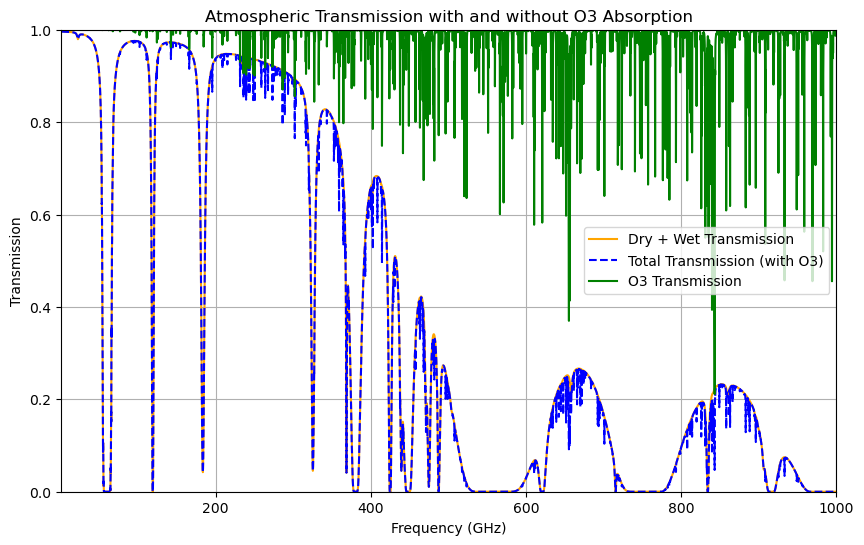

In [23]:
# Let's compare the total transmission with and without O3 absorption to see the impact of O3 on the overall transmission profile. We can plot both on the same graph for a clear comparison.

plt.figure(figsize=(10, 6))

plt.plot(frequencies_GHz, transmission_dry_wet, label='Dry + Wet Transmission', color='orange')
plt.plot(frequencies_GHz, transmission_tot, label='Total Transmission (with O3)', color='blue', linestyle='--')
plt.plot(frequencies_GHz, transmission_O3, label='O3 Transmission', color='green')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
#plt.xscale('log')
plt.title('Atmospheric Transmission with and without O3 Absorption')
plt.xlim(1, 1000)
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

In [60]:
#Here we'll see which threshold gives which  transmission

k_test= 3e-21   # cm^2 / molecule

absoprtion_profile_test = k_test * 0.1 * o3_density_interp[None, :] # in m-1
gamma_o3_test = absoprtion_profile_test * 10.0 / np.log(10) # in dB/km

transmission_O3_test = emission.attenuation_to_transmission(gamma_o3_test, dz_O3)

print(transmission_O3_test)

[0.97820575]


In [42]:
import numpy as np

# 1. Define the grid and conditions (0.1 GHz resolution)
frequencies_GHz = np.linspace(1, 1000, 10000)
T = 220.0    # K (Typical lower stratosphere)
P_tot = 30.0 # hPa 
P_o3 = 0.0   # hPa (O3 self-broadening negligible here)

# 2. Calculate the TRUE total cross-section spectrum
# (This evaluates the full sum of all 30,000+ lines on the 10,000 point grid)
k_o3_total = calculate_o3_uncoupled_absorption(
    frequencies_GHz, T, P_tot, P_o3,
    f0_cm, S_ref_cm, gam_air_cm, gam_self_cm, n_air, E_low_cm, delta_air_cm
)

# 3. Apply your threshold to find the "Active" frequency regions
k_threshold = 3e-21
active_grid_mask = k_o3_total > k_threshold

# Extract the specific frequencies where the absorption matters
active_frequencies_GHz = frequencies_GHz[active_grid_mask]

print(f"Total grid points: {len(frequencies_GHz)}")
print(f"Active grid points (> threshold): {len(active_frequencies_GHz)}")


# Convert HITRAN line centers to GHz for comparison
f0_GHz_lines = f0_cm * 29.9792458

# Define how far away a line can be from an active grid point to be kept
# 0.5 GHz covers the core and the near-wings of any significant line
keep_radius_GHz = 0.5

# Initialize a mask for the lines
keep_line_mask = np.zeros(len(f0_GHz_lines), dtype=bool)

# For each line, check if it is within 'keep_radius_GHz' of ANY active grid point.
# (Using np.searchsorted makes this extremely fast even for 30k lines)
indices = np.searchsorted(active_frequencies_GHz, f0_GHz_lines)

for i, f_line in enumerate(f0_GHz_lines):
    idx = indices[i]
    
    # Check the closest active frequency to the left
    if idx > 0 and abs(active_frequencies_GHz[idx - 1] - f_line) <= keep_radius_GHz:
        keep_line_mask[i] = True
    # Check the closest active frequency to the right
    elif idx < len(active_frequencies_GHz) and abs(active_frequencies_GHz[idx] - f_line) <= keep_radius_GHz:
        keep_line_mask[i] = True




Total grid points: 10000
Active grid points (> threshold): 1402


In [46]:
#Let's apply the mask to the hitran parameters

f0_cm_filtered_1 = f0_cm[keep_line_mask]
S_ref_cm_filtered_1 = S_ref_cm[keep_line_mask]
gam_air_cm_filtered_1 = gam_air_cm[keep_line_mask]
gam_self_cm_filtered_1 = gam_self_cm[keep_line_mask]
n_temp_filtered_1 = n_air[keep_line_mask]
E_low_cm_filtered_1 = E_low_cm[keep_line_mask]
delta_air_cm_filtered_1 = delta_air_cm[keep_line_mask]

k_o3_total_filtered_1 = calculate_o3_uncoupled_absorption(
    frequencies_GHz, T, P_tot, P_o3,
    f0_cm_filtered_1, S_ref_cm_filtered_1, gam_air_cm_filtered_1, 
    gam_self_cm_filtered_1, n_temp_filtered_1, E_low_cm_filtered_1, delta_air_cm_filtered_1
)


# 2. Compute the specific attenuation matrix (Nf, Nz)
# Using your exact corrected dimensional logic (* 0.1 to get km^-1)
alpha_km_filtered_1 = (k_o3_total_filtered_1[:, None] * o3_density_interp[None, :]) * 0.1

# 3. Convert to dB/km
gamma_o3_filtered_1 = alpha_km_filtered_1 * (10.0 / np.log(10.0))

# 4. Compute the final transmission array
# Assuming emission.attenuation_to_transmission integrates over the Nz axis
transmission_O3_filtered_1 = emission.attenuation_to_transmission(gamma_o3_filtered_1, dz_O3)



In [44]:
print(np.sum(keep_line_mask))

13274


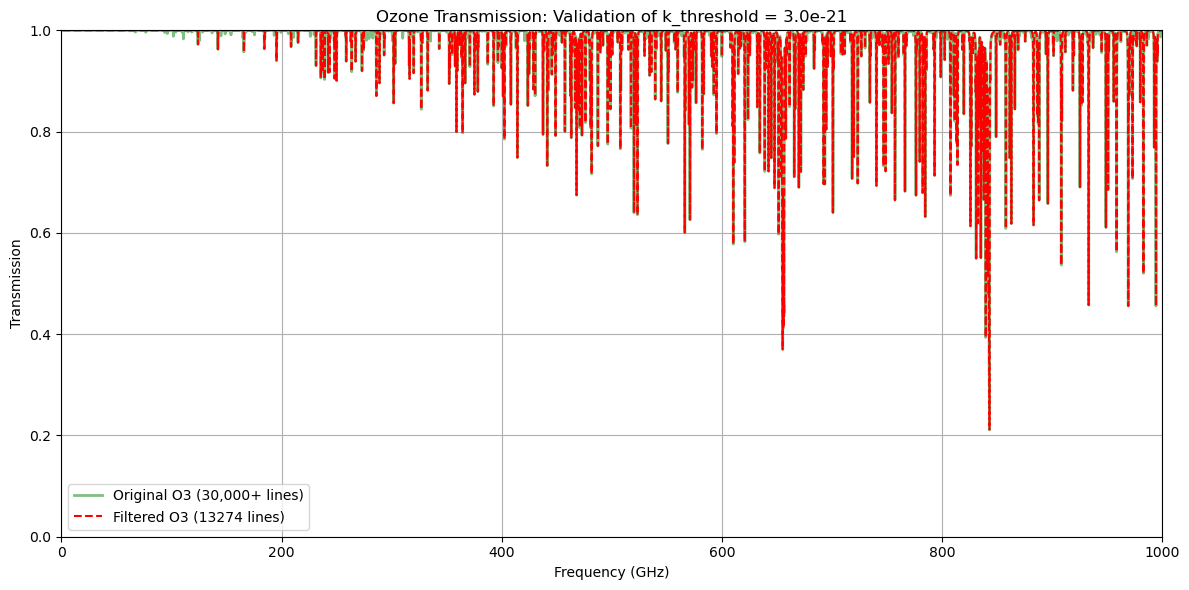

In [49]:

# ---------------------------------------------------------
# 5. Visual Validation (The Truth Test)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot the original transmission you calculated earlier (the dense grass)
# Assuming you saved your original transmission array as 'transmission_O3_original'
plt.plot(frequencies_GHz, transmission_O3, color='green', alpha=0.5, 
         label='Original O3 (30,000+ lines)', linewidth=2)

# Plot the new filtered transmission on top
plt.plot(frequencies_GHz, transmission_O3_filtered_1, color='red', linestyle='--', 
         label=f'Filtered O3 ({len(f0_cm_filtered_1)} lines)', linewidth=1.5)

plt.title(f"Ozone Transmission: Validation of k_threshold = {k_threshold:.1e}")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmission")
plt.ylim(0, 1)
plt.xlim(0, 1000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

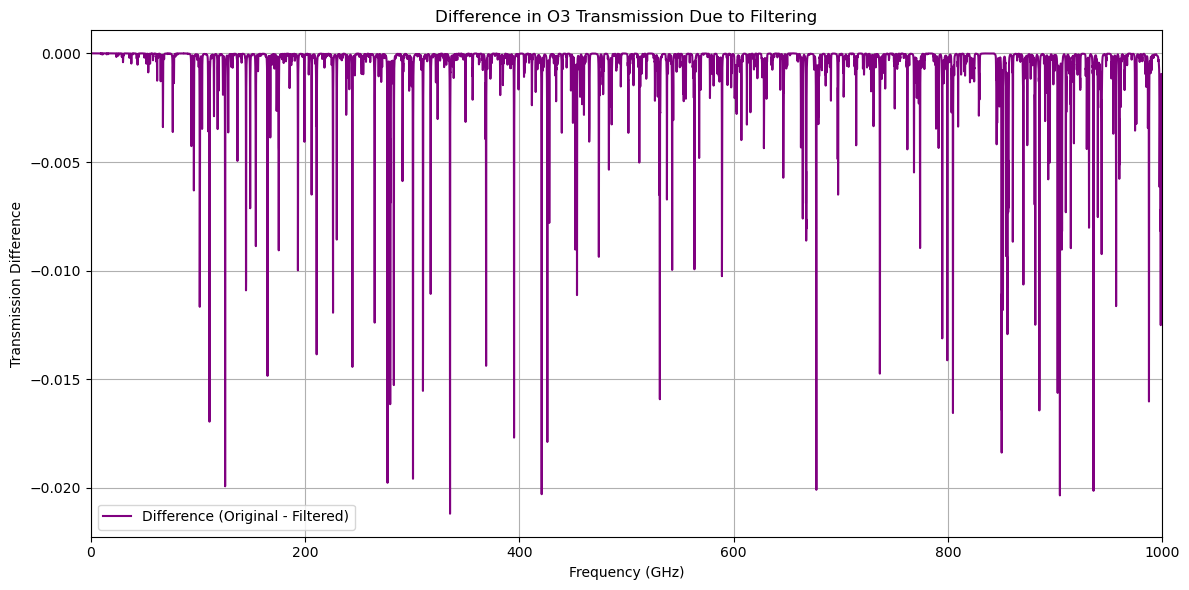

In [50]:
# Let's plot the total difference in transmission between the original and filtered O3 to see where the impact is most significant
plt.figure(figsize=(12, 6))
plt.plot(frequencies_GHz, transmission_O3 - transmission_O3_filtered_1, color='purple', label='Difference (Original - Filtered)')
plt.title("Difference in O3 Transmission Due to Filtering")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmission Difference")
plt.xlim(0, 1000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
import numpy as np
from hapi import partitionSum

def filter_o3_lines_by_exact_peak(
    T, P_total_hPa, P_o3_hPa, k_threshold,
    f0_cm, S_ref, gam_air, gam_self, n_temp, E_lower
):
    """
    Evaluates the exact peak cross-section of every O3 line at a specific
    temperature and pressure, and returns a mask of lines that exceed the threshold.
    """
    T_ref = 296.0
    c2 = 1.4387770
    
    # ---------------------------------------------------------
    # 1. Exact S(T) using HAPI
    # ---------------------------------------------------------
    Q_ratio = partitionSum(3, 1, T_ref) / partitionSum(3, 1, T)
    
    boltz_exponent = -c2 * E_lower * ((1.0 / T) - (1.0 / T_ref))
    boltz_factor = np.exp(boltz_exponent)
    
    stim_T = 1.0 - np.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - np.exp(-c2 * f0_cm / T_ref)
    stim_ratio = stim_T / stim_ref
    
    S_T = S_ref * Q_ratio * boltz_factor * stim_ratio
    
    # ---------------------------------------------------------
    # 2. Exact Line Width gamma(T, P)
    # ---------------------------------------------------------
    P_total_atm = P_total_hPa / 1013.25
    P_o3_atm = P_o3_hPa / 1013.25
    
    temp_scaling = (296.0 / T) ** n_temp
    gamma_width = temp_scaling * ((gam_air * (P_total_atm - P_o3_atm)) + (gam_self * P_o3_atm))
    
    # ---------------------------------------------------------
    # 3. The Peak Cross-Section (Gross Shape at nu = nu0)
    # ---------------------------------------------------------
    k_peak_exact = S_T / (np.pi * gamma_width)
    
    # 4. Create the Mask
    mask = k_peak_exact > k_threshold
    
    return mask, k_peak_exact

# --- Execution Example ---
# Typical stratospheric conditions where O3 peaks
T_strat = 220.0       # K
P_strat = 30.0        # hPa
P_o3_strat = 0.0      # Trace amount
k_threshold = 1e-21   # cm^2 / molecule

# Get the boolean mask of lines to keep
keep_mask, peak_values = filter_o3_lines_by_exact_peak(
    T_strat, P_strat, P_o3_strat, k_threshold,
    f0_cm, S_ref_cm, gam_air_cm, gam_self_cm, n_air, E_low_cm
)

# Apply the mask to your HITRAN arrays
f0_cm_filtered = f0_cm[keep_mask]
S_ref_cm_filtered = S_ref_cm[keep_mask]
gam_air_cm_filtered = gam_air_cm[keep_mask]
gam_self_cm_filtered = gam_self_cm[keep_mask]
n_temp_filtered = n_air[keep_mask]
E_low_cm_filtered = E_low_cm[keep_mask]
delta_air_cm_filtered = delta_air_cm[keep_mask]
# ... apply to all other arrays ...

print(f"Original O3 lines: {len(f0_cm)}")
print(f"Lines kept after true-peak filtering: {np.sum(keep_mask)}")

Original O3 lines: 33163
Lines kept after true-peak filtering: 459


In [39]:
print(peak_values[keep_mask])

[3.80393515e-21 5.17970028e-21 6.75091073e-21 6.15232488e-21
 8.40777049e-21 4.89922656e-21 4.34853289e-21 9.99344505e-21
 1.42028258e-20 1.41809664e-20 1.39452583e-20 1.36759127e-20
 1.27281535e-20 1.35087647e-20 9.33582648e-21 1.25977449e-20
 1.09170582e-20 1.29046872e-20 8.66008259e-21 1.13775065e-20
 5.85502545e-21 8.06415360e-21 1.22416538e-20 4.32032635e-21
 1.54418943e-20 7.64511218e-21 3.37617348e-21 2.18002916e-20
 1.06586378e-20 1.14456836e-20 1.34296374e-20 1.24144913e-20
 2.30562187e-20 3.78643676e-21 1.58084395e-20 5.82858908e-21
 3.21922809e-21 4.36028917e-21 1.77254668e-20 4.04790991e-21
 1.04921783e-20 7.52044507e-21 1.27564638e-20 9.08451651e-21
 3.25200940e-20 1.19856653e-20 3.82789360e-21 7.11572890e-21
 3.19052398e-20 1.50102615e-20 1.29463214e-20 1.90038990e-20
 5.54894147e-21 1.84368579e-20 4.18632926e-21 4.42377061e-21
 9.50274059e-21 2.21267488e-20 9.04656121e-21 4.29083223e-21
 1.18233320e-20 1.97505316e-20 4.11923940e-20 4.13505726e-21
 2.59333419e-20 5.006126

In [56]:
import matplotlib.pyplot as plt

# 1. Calculate the new cross-section spectrum using ONLY the filtered lines
# (Using the same stratospheric T and P you used for the baseline)
k_o3_filtered = calculate_o3_uncoupled_absorption(
    frequencies_GHz, T, P_tot, P_o3,
    f0_cm_filtered, S_ref_cm_filtered, gam_air_cm_filtered, 
    gam_self_cm_filtered, n_temp_filtered, E_low_cm_filtered, delta_air_cm_filtered
)

# 2. Compute the specific attenuation matrix (Nf, Nz)
# Using your exact corrected dimensional logic (* 0.1 to get km^-1)
alpha_km_filtered = (k_o3_filtered[:, None] * o3_density_interp[None, :]) * 0.1

# 3. Convert to dB/km
gamma_o3_filtered = alpha_km_filtered * (10.0 / np.log(10.0))

# 4. Compute the final transmission array
# Assuming emission.attenuation_to_transmission integrates over the Nz axis
transmission_O3_filtered = emission.attenuation_to_transmission(gamma_o3_filtered, dz_O3)


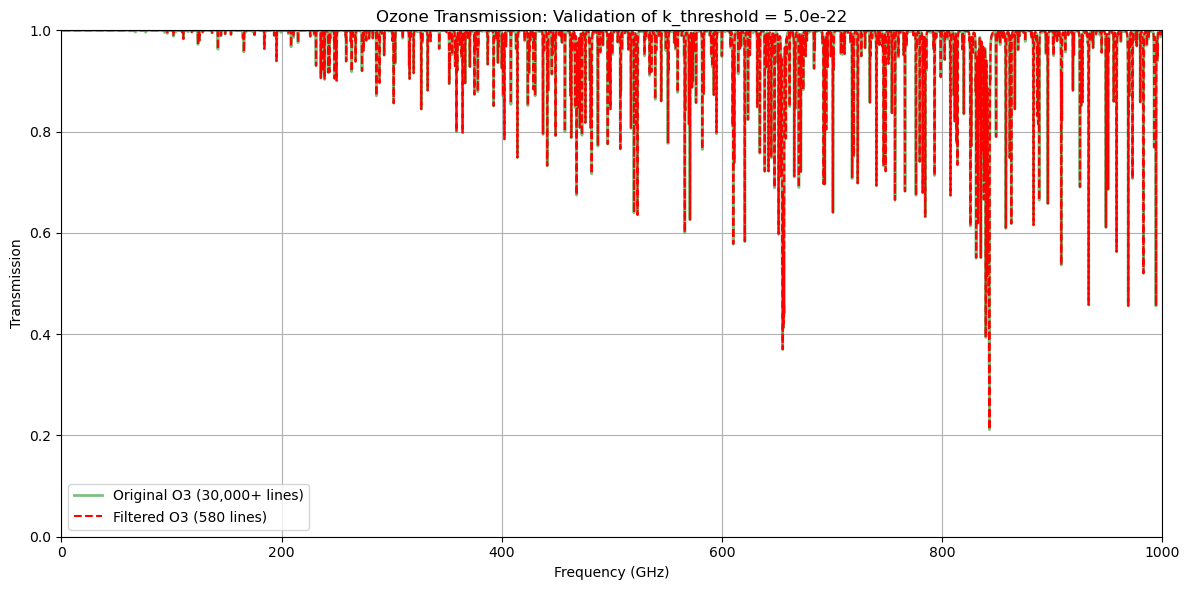

In [57]:

# ---------------------------------------------------------
# 5. Visual Validation (The Truth Test)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot the original transmission you calculated earlier (the dense grass)
# Assuming you saved your original transmission array as 'transmission_O3_original'
plt.plot(frequencies_GHz, transmission_O3, color='green', alpha=0.5, 
         label='Original O3 (30,000+ lines)', linewidth=2)

# Plot the new filtered transmission on top
plt.plot(frequencies_GHz, transmission_O3_filtered, color='red', linestyle='--', 
         label=f'Filtered O3 ({len(f0_cm_filtered)} lines)', linewidth=1.5)

plt.title(f"Ozone Transmission: Validation of k_threshold = {k_threshold:.1e}")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmission")
plt.ylim(0, 1)
plt.xlim(0, 1000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

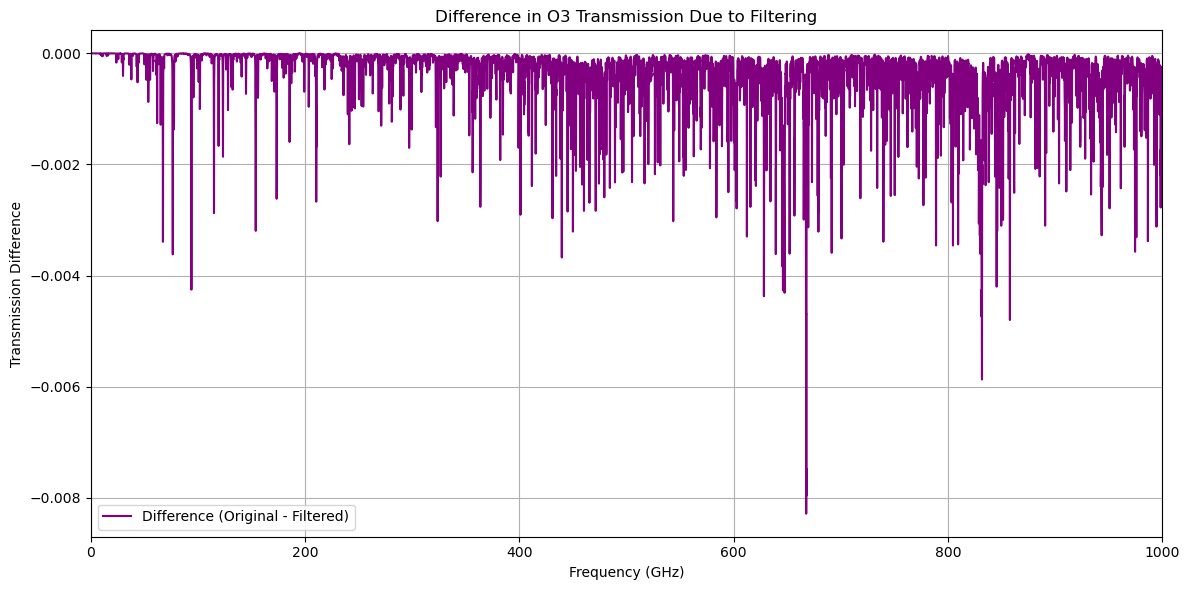

In [58]:
# Let's plot the total difference in transmission between the original and filtered O3 to see where the impact is most significant
plt.figure(figsize=(12, 6))
plt.plot(frequencies_GHz, transmission_O3 - transmission_O3_filtered, color='purple', label='Difference (Original - Filtered)')
plt.title("Difference in O3 Transmission Due to Filtering")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmission Difference")
plt.xlim(0, 1000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
print(o3_density_interp)

[8.38467433e+17 8.47828056e+17 8.49208837e+17 8.32438123e+17
 8.12891555e+17 7.88713501e+17 7.63775340e+17 7.35125091e+17
 7.04570968e+17 6.76520365e+17 6.56766264e+17 6.37012163e+17
 6.24856238e+17 6.19847206e+17 6.14838244e+17 6.08721660e+17
 6.01073526e+17 5.84575423e+17 5.63968891e+17 5.48676781e+17
 5.34862620e+17 5.27985106e+17 5.24399942e+17 5.25238457e+17
 5.35803836e+17 5.46369181e+17 5.82645093e+17 6.36778242e+17
 6.90911666e+17 7.99656665e+17 1.01695514e+18 1.23425458e+18
 1.45155409e+18 1.66885359e+18 1.93068621e+18 2.40291037e+18
 2.87513220e+18 3.34735650e+18 3.81958080e+18 4.24052058e+18
 4.29376141e+18 4.34700168e+18 4.40024196e+18 4.45348251e+18
 4.50672307e+18 4.55996334e+18 4.61320389e+18 4.65271045e+18
 4.60639737e+18 4.56008456e+18 4.51377121e+18 4.46745813e+18
 4.42114505e+18 4.37483225e+18 4.27256859e+18 4.14606071e+18
 4.01955393e+18 3.89304659e+18 3.76654008e+18 3.64003275e+18
 3.51352542e+18 3.38701863e+18 3.26051130e+18 3.13400396e+18
 3.00749663e+18 2.867827